# Email classification with Sentence Transformers and Random Forest

End-to-end pipeline for `data_v2`: load labels, preprocess email text, take a balanced 40% per-class training split, embed with Sentence Transformers, train a Random Forest, and evaluate on the remaining 60%.

In [1]:
# Fresh environments: %pip install sentence-transformers scikit-learn pandas
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
RANDOM_STATE = 42
DATA_DIR = Path('data_v2')


In [2]:
ground_truth = json.loads((DATA_DIR / 'ground_truth.json').read_text(encoding='utf-8'))
records = []
for path in sorted((DATA_DIR / 'inbox').glob('*.json')):
    email = json.loads(path.read_text(encoding='utf-8'))
    records.append({**email, 'label': ground_truth[email['email_id']]['category']})
df = pd.DataFrame(records)
print(f'Loaded {len(df)} emails')
display(df['label'].value_counts().sort_index().to_frame('records'))

Loaded 520 emails


,records
label,
BL_COMPARISON,220
GENERAL,60
INVOICE_QUERY,75
SI_REQUEST,125
SPAM,40


## Preprocessing

Subject and the current body are retained; forwarded/replied tails, signatures, warning boilerplate, URLs, email addresses, and punctuation noise are removed. This same function is used for both training and testing.

In [3]:
def preprocess_email(email):
    subject = str(email.get('subject', ''))
    body = str(email.get('body', ''))
    attachments = ' '.join(Path(str(x)).name.replace('_', ' ') for x in email.get('attachments', []))
    body = re.split(r'\n\s*(?:From:|-----Original Message-----|Best Regards|Kind regards)', body, flags=re.I)[0]
    body = re.sub(r'WARNING: This email originated outside.*?(?=\n|$)', ' ', body, flags=re.I | re.S)
    text = f'subject: {subject} body: {body} attachments: {attachments}'
    text = re.sub(r'https?://\S+|\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9_\s]', ' ', text).lower()
    return re.sub(r'\s+', ' ', text).strip()
df['processed_text'] = df.apply(preprocess_email, axis=1)
display(df[['subject', 'processed_text', 'label']].head(3))

,subject,processed_text,label
0,TO CONFIRM DOCS _ 5RSG-00133 _ CALLAO_PERU _ M...,subject to confirm docs _ 5rsg 00133 _ callao_...,BL_COMPARISON
1,RE_ LOCAL CHARGES FOB - KARGOSMAR - 5AKR-61849...,subject re_ local charges fob kargosmar 5akr 6...,INVOICE_QUERY
2,RE_ TO CONFIRM DOCS _ 5AAT-03056 _ AQABA_JORDA...,subject re_ to confirm docs _ 5aat 03056 _ aqa...,BL_COMPARISON


## Balanced 40% per-class split

Sampling is independent within each label. The test set is every remaining record and there is no ID overlap.

In [4]:
train_parts, test_parts = [], []
for label, group in df.groupby('label', sort=True):
    n_train = int(np.floor(len(group) * 0.40))
    train_group = group.sample(n=n_train, random_state=RANDOM_STATE)
    train_parts.append(train_group)
    test_parts.append(group.drop(train_group.index))
train_df = pd.concat(train_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_df = pd.concat(test_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
assert set(train_df.email_id).isdisjoint(test_df.email_id)
display(pd.DataFrame({'train': train_df.label.value_counts(), 'test': test_df.label.value_counts()}).sort_index())

,train,test
label,,
BL_COMPARISON,88,132
GENERAL,24,36
INVOICE_QUERY,30,45
SI_REQUEST,50,75
SPAM,16,24


## Sentence-transformer embeddings and Random Forest

In [5]:
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
X_train = embedding_model.encode(train_df.processed_text.tolist(), show_progress_bar=True, normalize_embeddings=True)
X_test = embedding_model.encode(test_df.processed_text.tolist(), show_progress_bar=True, normalize_embeddings=True)
classifier = RandomForestClassifier(n_estimators=500, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
classifier.fit(X_train, train_df.label)
predictions = classifier.predict(X_test)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

## Accuracy and evaluation

Test accuracy: 98.08% (306/312)
               precision    recall  f1-score   support

BL_COMPARISON      0.957     1.000     0.978       132
      GENERAL      1.000     0.833     0.909        36
INVOICE_QUERY      1.000     1.000     1.000        45
   SI_REQUEST      1.000     1.000     1.000        75
         SPAM      1.000     1.000     1.000        24

     accuracy                          0.981       312
    macro avg      0.991     0.967     0.977       312
 weighted avg      0.982     0.981     0.980       312



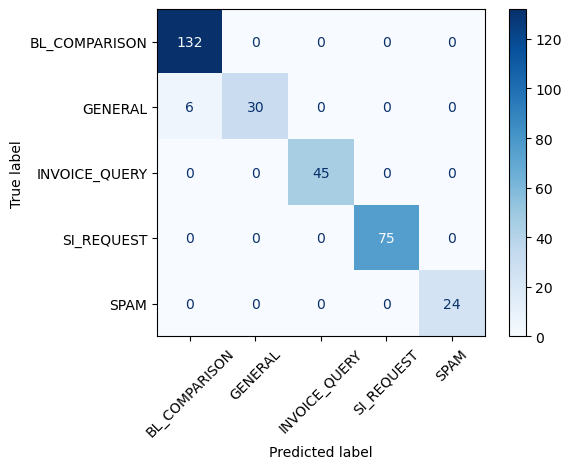

In [6]:
accuracy = accuracy_score(test_df.label, predictions)
print(f'Test accuracy: {accuracy:.2%} ({(predictions == test_df.label.to_numpy()).sum()}/{len(test_df)})')
print(classification_report(test_df.label, predictions, digits=3, zero_division=0))
ConfusionMatrixDisplay.from_predictions(test_df.label, predictions, xticks_rotation=45, cmap='Blues')
plt.tight_layout(); plt.show()

## Reusable prediction function

In [7]:
def predict_email(email):
    text = preprocess_email(email)
    vector = embedding_model.encode([text], normalize_embeddings=True)
    return classifier.predict(vector)[0]
example = test_df.iloc[0].to_dict()
print('Actual:', example['label'], '| Predicted:', predict_email(example))

Actual: SI_REQUEST | Predicted: SI_REQUEST
